# Experiment: Epistemic Uncertainty vs LSTM Depth

Objective:
- Compare the training-time epistemic uncertainty histograms for the `1L`, `2L`, and `3L` global no-embedding models.
- Check whether deeper LSTM stacks shift the uncertainty distribution downward, tighten it, or change how quickly it stabilizes across epochs.


In [5]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root from the current working directory.")


REPO_ROOT = find_repo_root()
RUN_ORDER = ["1L", "1L + TAGI-V", "2L",
            #  "3L"
             ]
RUN_PATHS = {
    "1L": REPO_ROOT / "experiments/out/seed17/train_use_100/Test_1L_global_no-embeddings/tracking/train_epistemic_uncertainty_histograms.npz",
    "1L + TAGI-V": REPO_ROOT / "experiments/out/seed17/train_use_100/Test_1L_global_no-embeddings_AGVI/tracking/train_epistemic_uncertainty_histograms.npz",
    "2L": REPO_ROOT / "experiments/out/seed17/train_use_100/Test_2L_global_no-embeddings/tracking/train_epistemic_uncertainty_histograms.npz",
    # "3L": REPO_ROOT / "experiments/out/seed17/train_use_100/Test_3L_global_no-embeddings/tracking/train_epistemic_uncertainty_histograms.npz",
}
COLORS = {
    "1L": "#c6dbef",
    "1L + TAGI-V": "#6baed6",
    "2L": "#3182bd",
    # "3L": "#08519c",
}
LINESTYLES = {"1L": "-", "1L + TAGI-V": "--", "2L": "-",
            #   "3L": "-"
              }

for label, path in RUN_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"{label} file not found: {path}")

RUN_PATHS


{'1L': PosixPath('/home/dw/cuTAGI_DW/experiments/out/seed17/train_use_100/Test_1L_global_no-embeddings/tracking/train_epistemic_uncertainty_histograms.npz'),
 '1L + TAGI-V': PosixPath('/home/dw/cuTAGI_DW/experiments/out/seed17/train_use_100/Test_1L_global_no-embeddings_AGVI/tracking/train_epistemic_uncertainty_histograms.npz'),
 '2L': PosixPath('/home/dw/cuTAGI_DW/experiments/out/seed17/train_use_100/Test_2L_global_no-embeddings/tracking/train_epistemic_uncertainty_histograms.npz')}

## Plan

- Normalize each histogram row so runs with slightly different sample counts remain comparable.
- Plot per-depth heatmaps over epochs to show where the uncertainty mass sits in log-space.
- Plot summary statistics to make the layer-depth trend easier to read: median, 95th percentile, IQR growth, and 90% range growth.


In [6]:
def load_histogram_run(path: Path, label: str) -> dict[str, np.ndarray]:
    with np.load(path) as data:
        counts = data["counts"].astype(float)
        row_sums = counts.sum(axis=1, keepdims=True)
        density = np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums > 0)

        quantile_levels = data["quantile_levels"].astype(float)
        quantiles = data["quantiles"].copy()
        log10_bin_centers = data["log10_bin_centers"].astype(float)

        def level_index(target: float) -> int:
            return int(np.argmin(np.abs(quantile_levels - target)))

        q05_idx = level_index(0.05)
        q25_idx = level_index(0.25)
        median_idx = level_index(0.5)
        q75_idx = level_index(0.75)
        q95_idx = level_index(0.95)

        bin_centers = np.power(10.0, log10_bin_centers)
        mean_uncertainty = (density * bin_centers[None, :]).sum(axis=1)

        log10_mean = (density * log10_bin_centers[None, :]).sum(axis=1)
        log10_var = (density * (log10_bin_centers[None, :] - log10_mean[:, None]) ** 2).sum(axis=1)
        log10_std = np.sqrt(log10_var)

        middle50_width = quantiles[:, q75_idx] - quantiles[:, q25_idx]
        central90_width = quantiles[:, q95_idx] - quantiles[:, q05_idx]
        central90_width_relative_to_start = np.divide(
            central90_width,
            central90_width[0],
            out=np.zeros_like(central90_width),
            where=central90_width[0] > 0,
        )

        return {
            "label": label,
            "epochs": data["epochs"].copy(),
            "log10_bin_edges": data["log10_bin_edges"].copy(),
            "log10_bin_centers": log10_bin_centers,
            "density": density,
            "sample_counts": data["sample_counts"].copy(),
            "quantile_levels": quantile_levels,
            "quantiles": quantiles,
            "log10_quantiles": data["log10_quantiles"].copy(),
            "mean_uncertainty": mean_uncertainty,
            "median_relative_to_start": data["median_relative_to_start"].copy(),
            "log10_std": log10_std,
            "middle50_width": middle50_width,
            "central90_width": central90_width,
            "central90_width_relative_to_start": central90_width_relative_to_start,
            "median_idx": median_idx,
            "q25_idx": q25_idx,
            "q75_idx": q75_idx,
            "q05_idx": q05_idx,
            "q95_idx": q95_idx,
        }


runs = {label: load_histogram_run(RUN_PATHS[label], label) for label in RUN_ORDER}

{
    label: {
        "epochs": len(run["epochs"]),
        "sample_counts_head": run["sample_counts"][:3].tolist(),
    }
    for label, run in runs.items()
}


{'1L': {'epochs': 22, 'sample_counts_head': [40645, 40961, 41239]},
 '1L + TAGI-V': {'epochs': 24, 'sample_counts_head': [40645, 40961, 41239]},
 '2L': {'epochs': 22, 'sample_counts_head': [40645, 40961, 41239]}}

In [7]:
summary_records = []
for label, run in runs.items():

    summary_records.append(
        {
            "layers": label,
            "n_epochs": int(len(run["epochs"])),
            "mean_epoch0": run["mean_uncertainty"][0],
            "mean_final": run["mean_uncertainty"][-1],
            "std_log10_epoch0": run["log10_std"][0],
            "std_log10_final": run["log10_std"][-1],
        }
    )

if pd is None:
    summary_df = None
    summary_records
else:
    summary_df = (
        pd.DataFrame(summary_records)
        .assign(display_order=lambda df: df["layers"].map({label: idx for idx, label in enumerate(RUN_ORDER)}))
        .sort_values("display_order")
        .drop(columns="display_order")
        .set_index("layers")
    )
    summary_df.round(4)


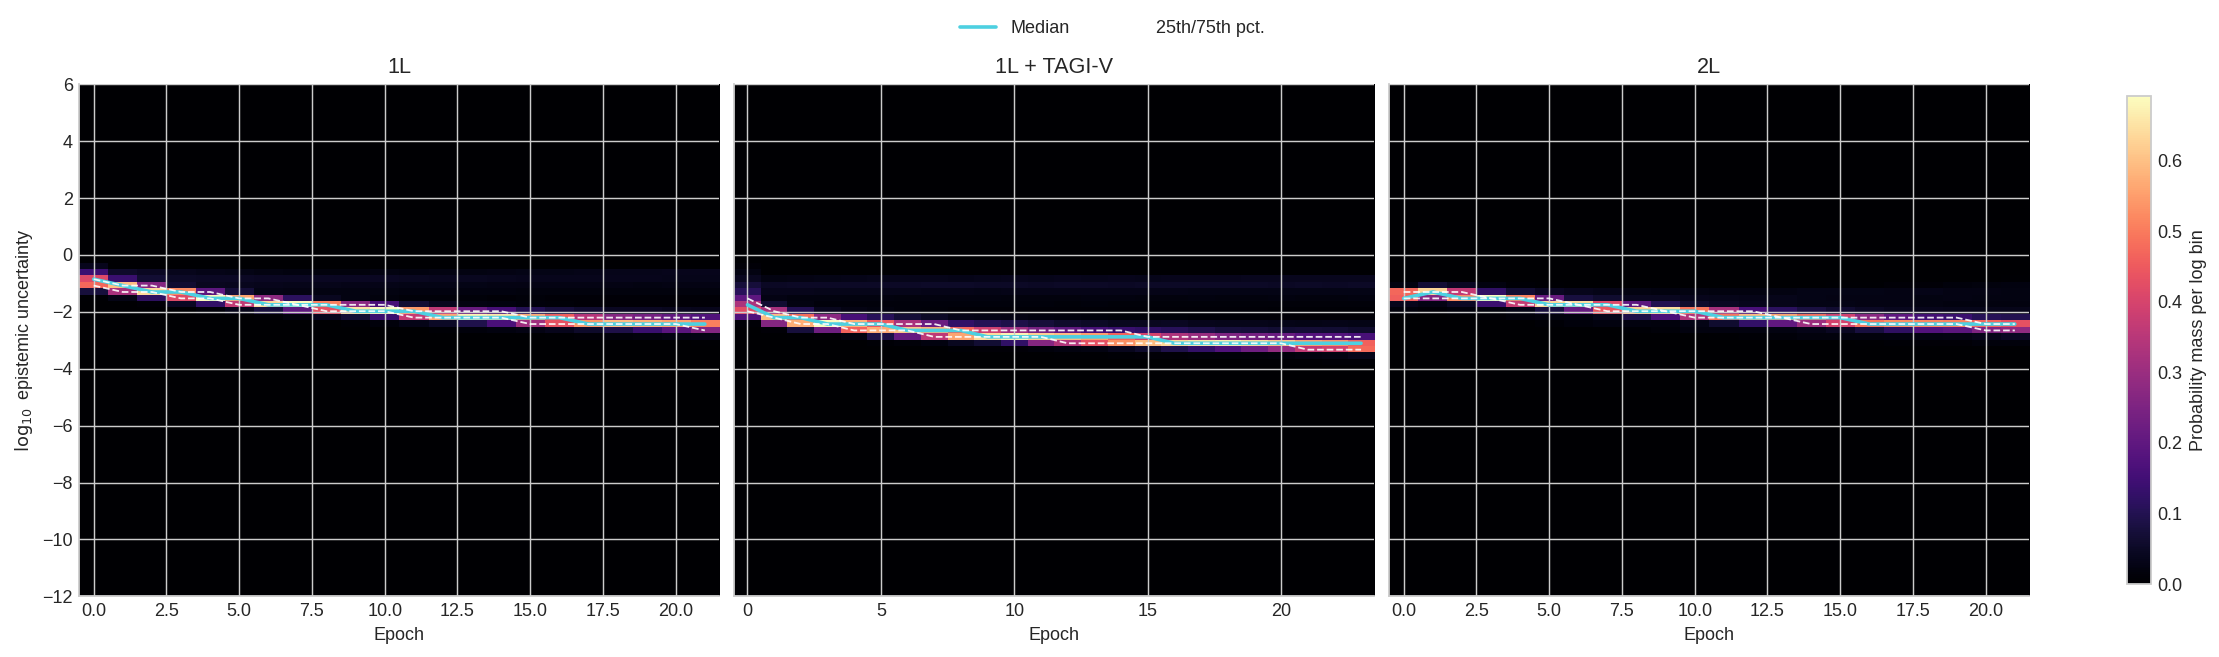

In [8]:
fig, axes = plt.subplots(1, len(runs), figsize=(17, 4.6), sharey=True, constrained_layout=True)

for ax, (label, run) in zip(axes, runs.items()):
    image = ax.imshow(
        run["density"].T,
        aspect="auto",
        origin="lower",
        extent=[
            run["epochs"][0] - 0.5,
            run["epochs"][-1] + 0.5,
            run["log10_bin_edges"][0],
            run["log10_bin_edges"][-1],
        ],
        cmap="magma",
    )
    ax.plot(
        run["epochs"],
        run["log10_quantiles"][:, run["median_idx"]],
        color="#4dd0e1",
        lw=2,
        label="Median",
    )
    ax.plot(
        run["epochs"],
        run["log10_quantiles"][:, run["q25_idx"]],
        color="white",
        lw=1,
        ls="--",
        alpha=0.9,
        label="25th/75th pct.",
    )
    ax.plot(
        run["epochs"],
        run["log10_quantiles"][:, run["q75_idx"]],
        color="white",
        lw=1,
        ls="--",
        alpha=0.9,
    )
    ax.set_title(label)
    ax.set_xlabel("Epoch")

axes[0].set_ylabel(r"$\log_{10}$ epistemic uncertainty")
handles, labels = axes[0].get_legend_handles_labels()
fig.colorbar(image, ax=axes, shrink=0.95, label="Probability mass per log bin")
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
plt.show()


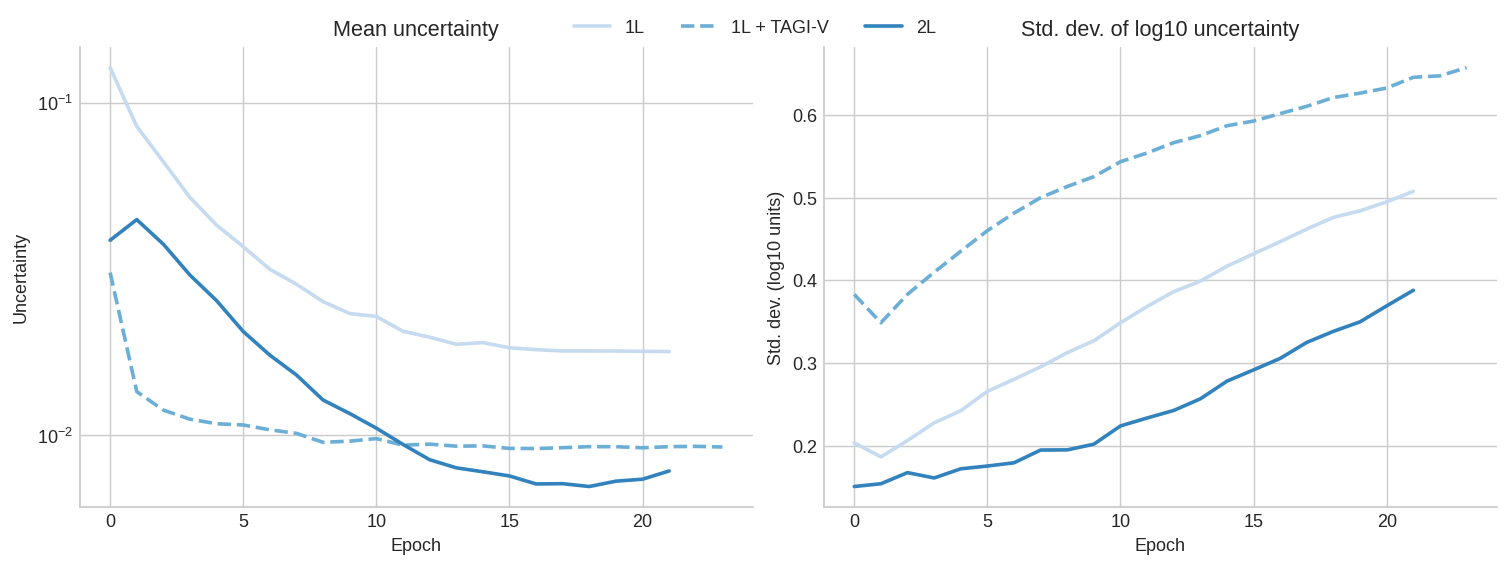

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharex=True, constrained_layout=True)
ax_mean, ax_std = axes

for label, run in runs.items():
    epochs = run["epochs"]
    color = COLORS[label]
    linestyle = LINESTYLES[label]

    ax_mean.plot(epochs, run["mean_uncertainty"], label=label, color=color, lw=2, ls=linestyle)
    ax_std.plot(epochs, run["log10_std"], label=label, color=color, lw=2, ls=linestyle)

ax_mean.set_title("Mean uncertainty")
ax_mean.set_yscale("log")
ax_mean.set_xlabel("Epoch")
ax_mean.set_ylabel("Uncertainty")

ax_std.set_title("Std. dev. of log10 uncertainty")
ax_std.set_xlabel("Epoch")
ax_std.set_ylabel("Std. dev. (log10 units)")

handles, labels = ax_mean.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.show()


## Reading the plots

- Lower heatmap mass and lower quantile curves mean less epistemic uncertainty.
- `median_final_over_start < 1` means the typical uncertainty decreased over training; smaller values indicate a larger drop.
- The standard-deviation panel is computed in `log10` space, so it reflects how many orders of magnitude the uncertainty distribution spans around its center.
- The middle-50% panel shows the literal `Q3 - Q1` width, which is easier to read as an absolute spread than the earlier multiplicative IQR ratio.
- In the `90% width / epoch-0 width` panel, `1.0` means the central 90% width matches epoch 0, values below `1.0` mean it tightened, and values above `1.0` mean it widened.
- The `3L` run has one extra epoch, so compare the shared epoch window first and treat the final `3L` point as an additional late-training snapshot.
